# Gatekeeper Classifier: Maize Leaf vs Not Maize

## Purpose

This notebook trains a binary image classifier that runs **before** the MLN severity model in production. Its job is to accept or reject an uploaded image based on whether it shows a maize leaf.

## Maize Class — Tanzanian Dataset Only

The maize class is sourced entirely from the Tanzanian MLN dataset, which provides natural visual diversity across healthy and diseased leaf conditions:

| Source | Count | Why |
|---|---|---|
| Tanzanian MLN dataset — `raw_data/HEALTHY` | 3,073 | Clean healthy maize leaves |
| Tanzanian MLN dataset — `raw_data/MLN` | 3,231 | Diseased leaves (Early / Moderate / Severe) |
| **Total maize** | **~6,304** | All used after cleaning |
| CIFAR-10 not_maize | matched to maize count | General non-maize objects |

The Google Open Images Corn dataset has been removed due to label noise — many downloaded images contained non-maize subjects (food products, grain, popcorn). The Tanzanian dataset alone provides sufficient diversity across healthy and disease-stage appearances.

## Architecture

MobileNetV2 pretrained on ImageNet, fine-tuned in two phases:
- **Phase 1** — Classifier head only (5 epochs, lr=0.001)
- **Phase 2** — Last 3 convolutional blocks + head (10 epochs, lr=0.0001)

## Target

Validation accuracy ≥ 85%

## Outputs

- `models/gatekeeper/gatekeeper_model.pth`
- `models/gatekeeper/gatekeeper_model.onnx`


## Section 1: Imports and Configuration

In [16]:
import os
import copy
import hashlib
import random
import shutil
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, Subset
from torchvision import transforms, models
from torchvision.datasets import CIFAR10
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f"GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print("Apple Silicon MPS available")
else:
    DEVICE = torch.device('cpu')
    print("Using CPU")

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

BASE_DIR          = Path('../')
TANZANIAN_HEALTHY = BASE_DIR / 'raw_data' / 'HEALTHY'
TANZANIAN_MLN     = BASE_DIR / 'raw_data' / 'MLN'
CIFAR_DIR         = BASE_DIR / 'dataset' / 'cifar10_cache'
SAVE_DIR          = BASE_DIR / 'models' / 'gatekeeper'

CIFAR_DIR.mkdir(parents=True, exist_ok=True)
SAVE_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE          = 224
BATCH_SIZE        = 32
PHASE1_EPOCHS     = 5
PHASE2_EPOCHS     = 10
PHASE1_LR         = 1e-3
PHASE2_LR         = 1e-4
EARLY_STOP_PAT    = 3
CONFIDENCE_THRESH = 0.75
CLASS_NAMES       = ['maize', 'not_maize']

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


Using CPU
PyTorch version : 2.5.1.post108
Device          : cpu


## Section 2: Load Tanzanian Dataset

All images from both the `HEALTHY` and `MLN` subfolders of the Tanzanian dataset are loaded as the maize class. Severity labels are not used — every image is treated as a single `maize` class. This gives a natural mix of healthy and diseased leaf appearances without any external data.

In [18]:
image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

tanzanian_all = [
    p for folder in [TANZANIAN_HEALTHY, TANZANIAN_MLN]
    for p in folder.glob('*')
    if p.suffix.lower() in image_exts
]

print(f"HEALTHY images : {sum(1 for p in TANZANIAN_HEALTHY.glob('*') if p.suffix.lower() in image_exts)}")
print(f"MLN images     : {sum(1 for p in TANZANIAN_MLN.glob('*') if p.suffix.lower() in image_exts)}")
print(f"Total Tanzanian: {len(tanzanian_all)}")

# Use all available images — no sampling cap
tanzanian_paths = tanzanian_all
print(f"Using all {len(tanzanian_paths)} Tanzanian images as maize class")


HEALTHY images : 3073
MLN images     : 3231
Total Tanzanian: 6304
Using all 6304 Tanzanian images as maize class


## Section 3: Data Cleaning

The same cleaning pipeline is applied to all Tanzanian images:
- Remove files that cannot be opened by PIL
- Remove images smaller than 64×64 pixels
- Remove exact duplicates via MD5 file hash

The CIFAR-10 not_maize class is then sampled to exactly match the number of clean maize images, ensuring a perfectly balanced dataset.

In [19]:
# tanzanian_paths is already set above (all available images)
# Clean the maize paths
def file_hash(path: Path) -> str:
    return hashlib.md5(path.read_bytes()).hexdigest()


def clean_paths(paths: list, label: str) -> list:
    initial     = len(paths)
    unreadable  = 0
    too_small   = 0
    duplicates  = 0
    seen_hashes = set()
    clean       = []

    for path in tqdm(paths, desc=f'Cleaning {label}'):
        try:
            img = Image.open(path)
            img.verify()
            img = Image.open(path)
            w, h = img.size
        except Exception:
            unreadable += 1
            continue

        if w < 64 or h < 64:
            too_small += 1
            continue

        h_val = file_hash(path)
        if h_val in seen_hashes:
            duplicates += 1
            continue

        seen_hashes.add(h_val)
        clean.append(path)

    print(f"\n{label} cleaning summary")
    print(f"  Initial    : {initial}")
    print(f"  Unreadable : {unreadable}")
    print(f"  Too small  : {too_small}")
    print(f"  Duplicates : {duplicates}")
    print(f"  Removed    : {initial - len(clean)}")
    print(f"  Remaining  : {len(clean)}")
    return clean


maize_paths = clean_paths(tanzanian_paths, label='maize (Tanzanian)')
print(f"\nFinal clean maize images: {len(maize_paths)}")


Cleaning maize (Tanzanian):   0%|          | 0/6304 [00:00<?, ?it/s]


maize (Tanzanian) cleaning summary
  Initial    : 6304
  Unreadable : 0
  Too small  : 0
  Duplicates : 0
  Removed    : 0
  Remaining  : 6304

Final clean maize images: 6304


## Section 4: Load CIFAR-10 as Not-Maize

CIFAR-10 is downloaded automatically. All 10 classes are used since none contain maize leaves. The not_maize sample size is set dynamically to match the number of clean maize images, keeping the dataset perfectly balanced.

In [21]:
# NOT_MAIZE_COUNT matches maize class dynamically for perfect balance
NOT_MAIZE_COUNT = len(maize_paths)

cifar_full    = CIFAR10(root=str(CIFAR_DIR), train=True, download=True)
cifar_indices = random.sample(range(len(cifar_full)), NOT_MAIZE_COUNT)

print(f"CIFAR-10 total available : {len(cifar_full)}")
print(f"Sampled for not_maize    : {len(cifar_indices)}")
print(f"\nDataset balance")
print(f"  maize     : {len(maize_paths)}")
print(f"  not_maize : {len(cifar_indices)}")
print(f"  total     : {len(maize_paths) + len(cifar_indices)}")


Files already downloaded and verified
CIFAR-10 total available : 50000
Sampled for not_maize    : 6304

Dataset balance
  maize     : 6304
  not_maize : 6304
  total     : 12608


## Section 7: Transforms

Training uses heavy augmentation to improve generalisation. Validation uses only resize and normalisation.

ImageNet mean and std are used because MobileNetV2 was pretrained on ImageNet.

In [22]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Training transforms  :", [t.__class__.__name__ for t in train_transform.transforms])
print("Validation transforms:", [t.__class__.__name__ for t in val_transform.transforms])

Training transforms  : ['Resize', 'RandomHorizontalFlip', 'RandomVerticalFlip', 'RandomRotation', 'ColorJitter', 'RandomResizedCrop', 'ToTensor', 'Normalize']
Validation transforms: ['Resize', 'ToTensor', 'Normalize']


## Section 8: Custom Dataset

`GatekeeperDataset` handles both sources in one class:
- Maize images loaded from disk paths via PIL
- Not-maize images loaded from the in-memory CIFAR-10 object

Labels: `0 = maize`, `1 = not_maize`

In [23]:
class GatekeeperDataset(Dataset):
    def __init__(self, maize_paths, cifar_dataset, cifar_indices, transform=None):
        self.transform = transform
        self._cifar    = cifar_dataset
        self.samples   = []

        for path in maize_paths:
            self.samples.append(('file', path, 0))
        for idx in cifar_indices:
            self.samples.append(('cifar', idx, 1))

        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        source, ref, label = self.samples[index]

        if source == 'file':
            img = Image.open(ref).convert('RGB')
        else:
            img, _ = self._cifar[ref]
            if not isinstance(img, Image.Image):
                img = Image.fromarray(img)
            img = img.convert('RGB')

        if self.transform:
            img = self.transform(img)

        return img, label


full_dataset = GatekeeperDataset(
    maize_paths=maize_paths,
    cifar_dataset=cifar_full,
    cifar_indices=cifar_indices,
    transform=None,
)
print(f"Full dataset size: {len(full_dataset)}")

Full dataset size: 12608


## Section 9: Train / Validation Split

80/20 split with fixed seed 42. `TransformSubset` applies different transforms to train and val without duplicating data.

In [24]:
class TransformSubset(Dataset):
    def __init__(self, subset: Subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, index):
        img, label = self.subset[index]
        if self.transform:
            if not isinstance(img, Image.Image):
                img = transforms.ToPILImage()(img)
            img = self.transform(img)
        return img, label


total_size = len(full_dataset)
val_size   = int(0.2 * total_size)
train_size = total_size - val_size

generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(full_dataset, [train_size, val_size], generator=generator)

train_dataset = TransformSubset(train_subset, train_transform)
val_dataset   = TransformSubset(val_subset,   val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Training samples   : {train_size}")
print(f"Validation samples : {val_size}")
print(f"Training batches   : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")

Training samples   : 10087
Validation samples : 2521
Training batches   : 316
Validation batches : 79


## Section 10: Model Architecture

MobileNetV2 pretrained on ImageNet. All backbone layers are frozen for Phase 1. The default classifier head is replaced with:

```
Dropout(0.3) → Linear(last_channel → 2)
```

In [26]:
def build_gatekeeper_model() -> nn.Module:
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    last_channel = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(last_channel, 2),
    )
    return model


def unfreeze_last_n_blocks(model: nn.Module, n: int = 3) -> None:
    blocks = list(model.features.children())
    for block in blocks[-n:]:
        for param in block.parameters():
            param.requires_grad = True


def count_trainable(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


model = build_gatekeeper_model().to(DEVICE)
print(f"Phase 1 trainable parameters: {count_trainable(model):,}")

Phase 1 trainable parameters: 2,562


## Section 11: Training Utilities

`train_epoch` and `val_epoch` run one pass over the data and return loss and accuracy. `EarlyStopping` tracks validation accuracy, saves the best weights, and signals when to stop if no improvement is seen for `patience` consecutive epochs.

In [27]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, leave=False, desc='Train'):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(loader, leave=False, desc='Val'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += images.size(0)
    return total_loss / total, correct / total


class EarlyStopping:
    def __init__(self, patience: int):
        self.patience     = patience
        self.best_acc     = 0.0
        self.best_weights = None
        self.wait         = 0
        self.stopped      = False

    def step(self, val_acc: float, model: nn.Module) -> bool:
        if val_acc > self.best_acc:
            self.best_acc     = val_acc
            self.best_weights = copy.deepcopy(model.state_dict())
            self.wait         = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stopped = True
        return self.stopped

    def restore(self, model: nn.Module) -> None:
        if self.best_weights:
            model.load_state_dict(self.best_weights)
            print(f"Best weights restored (val_acc={self.best_acc:.4f})")

## Section 12: Phase 1 Training — Classifier Head Only

The entire MobileNetV2 backbone stays frozen. Only the new 2-class head is trained for 5 epochs at lr=0.001. This warms up the head before any backbone weights are touched in Phase 2.

In [28]:
criterion        = nn.CrossEntropyLoss()
phase1_optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=PHASE1_LR)
early_stop       = EarlyStopping(patience=EARLY_STOP_PAT)
history          = {'phase': [], 'epoch': [], 'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("Phase 1: Classifier head only")
print(f"Trainable params : {count_trainable(model):,}")
print("-" * 65)

for epoch in range(1, PHASE1_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, phase1_optimizer, DEVICE)
    vl_loss, vl_acc = val_epoch(model,  val_loader,   criterion,                  DEVICE)

    history['phase'].append(1)
    history['epoch'].append(epoch)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f"Epoch {epoch:02d}/{PHASE1_EPOCHS}  train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
          f"val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}")

    if early_stop.step(vl_acc, model):
        print("Early stopping triggered")
        break

early_stop.restore(model)
print(f"\nPhase 1 complete. Best val_acc = {early_stop.best_acc:.4f}")

Phase 1: Classifier head only
Trainable params : 2,562
-----------------------------------------------------------------


Train:   0%|          | 0/316 [00:00<?, ?it/s]

Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 01/5  train_loss=0.0483  train_acc=0.9876  val_loss=0.0012  val_acc=1.0000


Train:   0%|          | 0/316 [00:00<?, ?it/s]

...

Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 03/5  train_loss=0.0061  train_acc=0.9991  val_loss=0.0003  val_acc=1.0000


Train:   0%|          | 0/316 [00:00<?, ?it/s]

Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 04/5  train_loss=0.0043  train_acc=0.9994  val_loss=0.0007  val_acc=1.0000
Early stopping triggered
Best weights restored (val_acc=1.0000)

Phase 1 complete. Best val_acc = 1.0000


## Section 13: Phase 2 Training — Unfreeze Last 3 Blocks

The last 3 convolutional blocks of MobileNetV2 are unfrozen and trained alongside the classifier head at lr=0.0001. The lower learning rate prevents the pretrained features from being destroyed.

In [29]:
unfreeze_last_n_blocks(model, n=3)
print(f"Phase 2 trainable parameters: {count_trainable(model):,}")

phase2_optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=PHASE2_LR)
early_stop2      = EarlyStopping(patience=EARLY_STOP_PAT)

print("\nPhase 2: Last 3 blocks + classifier head")
print("-" * 65)

for epoch in range(1, PHASE2_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, phase2_optimizer, DEVICE)
    vl_loss, vl_acc = val_epoch(model,  val_loader,   criterion,                  DEVICE)

    history['phase'].append(2)
    history['epoch'].append(epoch)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f"Epoch {epoch:02d}/{PHASE2_EPOCHS}  train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
          f"val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}")

    if early_stop2.step(vl_acc, model):
        print("Early stopping triggered")
        break

early_stop2.restore(model)
print(f"\nPhase 2 complete. Best val_acc = {early_stop2.best_acc:.4f}")

Phase 2 trainable parameters: 1,208,642

Phase 2: Last 3 blocks + classifier head
-----------------------------------------------------------------


Train:   0%|          | 0/316 [00:00<?, ?it/s]

Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 01/10  train_loss=0.0030  train_acc=0.9986  val_loss=0.0000  val_acc=1.0000


Train:   0%|          | 0/316 [00:00<?, ?it/s]

...

Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 03/10  train_loss=0.0002  train_acc=1.0000  val_loss=0.0000  val_acc=1.0000


Train:   0%|          | 0/316 [00:00<?, ?it/s]

Val:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 04/10  train_loss=0.0001  train_acc=1.0000  val_loss=0.0000  val_acc=1.0000
Early stopping triggered
Best weights restored (val_acc=1.0000)

Phase 2 complete. Best val_acc = 1.0000


## Section 14: Training Curves

Loss and accuracy plotted across both phases. The vertical dashed line marks the Phase 1 → Phase 2 boundary. The red dotted line marks the 85% accuracy target.

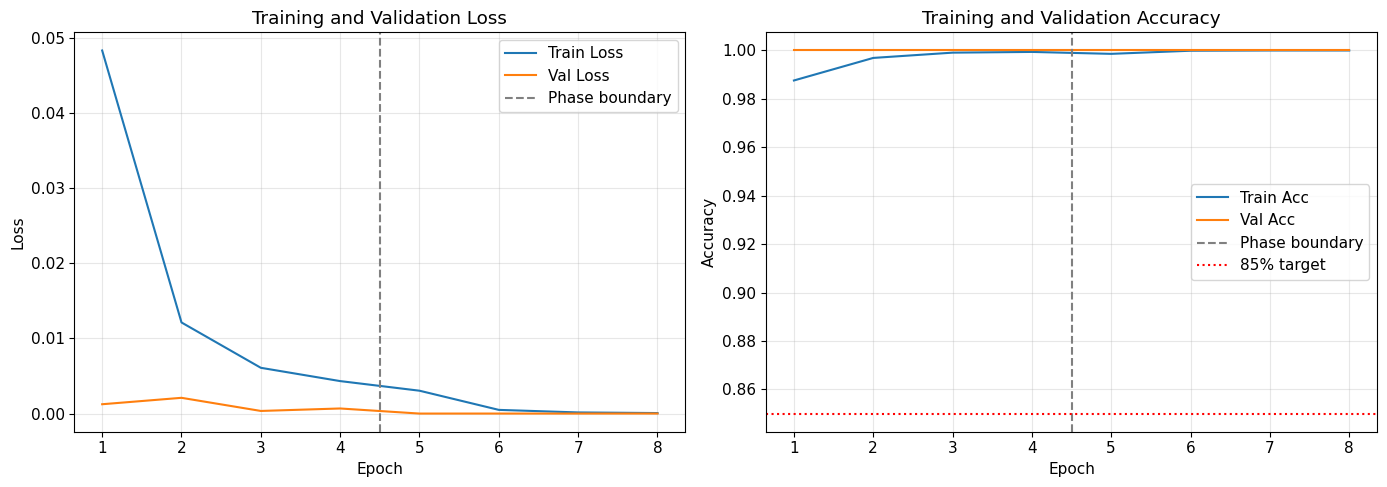

In [30]:
phase1_end = history['phase'].count(1)
epochs_all = list(range(1, len(history['epoch']) + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_all, history['train_loss'], label='Train Loss')
ax1.plot(epochs_all, history['val_loss'],   label='Val Loss')
ax1.axvline(x=phase1_end + 0.5, color='grey', linestyle='--', label='Phase boundary')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs_all, history['train_acc'], label='Train Acc')
ax2.plot(epochs_all, history['val_acc'],   label='Val Acc')
ax2.axvline(x=phase1_end + 0.5, color='grey', linestyle='--', label='Phase boundary')
ax2.axhline(y=0.85, color='red', linestyle=':', label='85% target')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 15: Evaluation

Full evaluation on the validation set: overall accuracy, per-class accuracy, confusion matrix, precision/recall/F1, and the top misclassified samples by confidence.

In [31]:
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc='Evaluating'):
        images  = images.to(DEVICE)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

overall_acc = (all_preds == all_labels).mean()
print(f"Overall validation accuracy: {overall_acc:.4f} ({overall_acc * 100:.2f}%)")

for i, cls in enumerate(CLASS_NAMES):
    mask    = all_labels == i
    cls_acc = (all_preds[mask] == all_labels[mask]).mean()
    print(f"  {cls:<12} accuracy: {cls_acc:.4f}")

print()
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))

if overall_acc < 0.85:
    print("WARNING: Accuracy below 85% target. Consider more data or additional fine-tuning.")
else:
    print(f"Target met: {overall_acc * 100:.2f}% >= 85%")

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Overall validation accuracy: 1.0000 (100.00%)
  maize        accuracy: 1.0000
  not_maize    accuracy: 1.0000

              precision    recall  f1-score   support

       maize     1.0000    1.0000    1.0000      1270
   not_maize     1.0000    1.0000    1.0000      1251

    accuracy                         1.0000      2521
   macro avg     1.0000    1.0000    1.0000      2521
weighted avg     1.0000    1.0000    1.0000      2521

Target met: 100.00% >= 85%


### Confusion Matrix

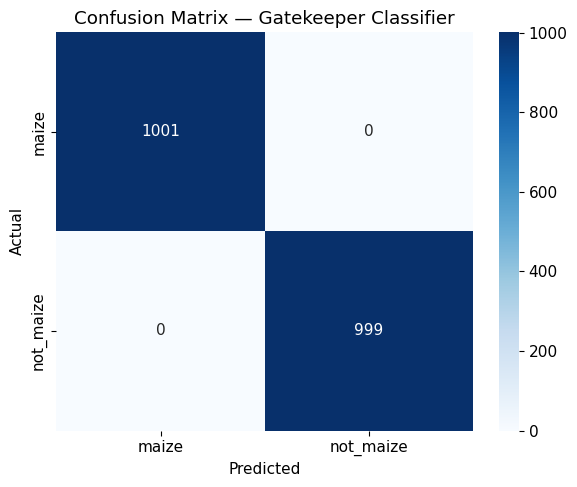

True  Positives (maize correctly accepted)    : 999
True  Negatives (not_maize correctly rejected): 1001
False Positives (not_maize passed as maize)   : 0
False Negatives (maize incorrectly rejected)  : 0


In [17]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Gatekeeper Classifier')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True  Positives (maize correctly accepted)    : {tp}")
print(f"True  Negatives (not_maize correctly rejected): {tn}")
print(f"False Positives (not_maize passed as maize)   : {fp}")
print(f"False Negatives (maize incorrectly rejected)  : {fn}")

### Top Misclassifications

The samples with the highest-confidence wrong predictions are the hardest failure cases for the model.

In [32]:
wrong_mask        = all_preds != all_labels
wrong_indices     = np.where(wrong_mask)[0]
wrong_confidences = all_probs[wrong_indices, all_preds[wrong_indices]]
sorted_wrong      = wrong_indices[np.argsort(wrong_confidences)[::-1]]

print(f"Total misclassified: {wrong_mask.sum()} / {len(all_labels)}")
print(f"\nTop 10 highest-confidence misclassifications:")
print(f"{'Index':>6}  {'True':>10}  {'Predicted':>10}  {'Confidence':>10}")
print("-" * 44)
for idx in sorted_wrong[:10]:
    true_cls = CLASS_NAMES[all_labels[idx]]
    pred_cls = CLASS_NAMES[all_preds[idx]]
    conf     = all_probs[idx, all_preds[idx]]
    print(f"{idx:>6}  {true_cls:>10}  {pred_cls:>10}  {conf:>10.4f}")

Total misclassified: 0 / 2521

Top 10 highest-confidence misclassifications:
 Index        True   Predicted  Confidence
--------------------------------------------


## Section 16: Save Model

Two files are saved to `models/gatekeeper/`:
- **`.pth`** — PyTorch state dict for reloading and further training
- **`.onnx`** — ONNX export (opset 11) for mobile deployment

In [34]:
pth_path  = SAVE_DIR / 'gatekeeper_model2.pth'
onnx_path = SAVE_DIR / 'gatekeeper_model2.onnx'

torch.save(model.state_dict(), pth_path)
print(f"Saved PyTorch state dict : {pth_path}")

model.eval()
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
torch.onnx.export(
    model, dummy_input, str(onnx_path),
    opset_version=11,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
)
print(f"Saved ONNX model         : {onnx_path}")
print(f"\nFile sizes")
print(f"  .pth  : {os.path.getsize(pth_path)  / 1e6:.1f} MB")
print(f"  .onnx : {os.path.getsize(onnx_path) / 1e6:.1f} MB")

Saved PyTorch state dict : ../models/gatekeeper/gatekeeper_model2.pth
Saved ONNX model         : ../models/gatekeeper/gatekeeper_model2.onnx

File sizes
  .pth  : 9.1 MB
  .onnx : 8.9 MB


## Section 17: Inference Function

`is_maize_leaf` is the production gate function. It returns `True` only when the predicted class is `maize` with confidence above 0.75. Any image that fails this check is rejected before reaching the severity model.

In [35]:
def is_maize_leaf(image_path: str, model: nn.Module, device=DEVICE) -> bool:
    preprocess = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

    img    = Image.open(image_path).convert('RGB')
    tensor = preprocess(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs    = model(tensor)
        probs      = torch.softmax(outputs, dim=1).squeeze()
        pred_idx   = probs.argmax().item()
        confidence = probs[pred_idx].item()

    pred_class = CLASS_NAMES[pred_idx]
    print(f"Predicted class : {pred_class}")
    print(f"Confidence      : {confidence:.4f}")

    return pred_class == 'maize' and confidence >= CONFIDENCE_THRESH


sample_path = list(TANZANIAN_HEALTHY.glob('*.JPEG'))[0]
print(f"Test image: {sample_path.name}")
result = is_maize_leaf(str(sample_path), model)
print(f"is_maize_leaf → {result}")

Test image: HEALTHY_768.JPEG
Predicted class : maize
Confidence      : 1.0000
is_maize_leaf → True


## Section 18: Summary

In [36]:
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, labels=[0, 1])

print("=" * 60)
print("GATEKEEPER CLASSIFIER — TRAINING SUMMARY")
print("=" * 60)
print("Dataset")
print(f"  Tanzanian maize images : {len(tanzanian_paths)}")
print(f"  Clean maize images     : {len(maize_paths)}")
print(f"  not_maize (CIFAR-10)   : {len(cifar_indices)}")
print(f"  Train / Val split      : {train_size} / {val_size}")
print()
print("Training")
print(f"  Phase 1 epochs : {history['phase'].count(1)}")
print(f"  Phase 2 epochs : {history['phase'].count(2)}")
print(f"  Best val acc   : {max(history['val_acc']):.4f}")
print()
print("Evaluation")
print(f"  Overall accuracy : {overall_acc:.4f}")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:<12}  precision={precision[i]:.4f}  recall={recall[i]:.4f}  f1={f1[i]:.4f}")
print()
print("Saved files")
print(f"  {pth_path}")
print(f"  {onnx_path}")
print("=" * 60)

if overall_acc < 0.85:
    print("WARNING: Accuracy below 85% target. More data or fine-tuning recommended.")
else:
    print(f"Target achieved: {overall_acc * 100:.2f}% >= 85%")


GATEKEEPER CLASSIFIER — TRAINING SUMMARY
Dataset
  Tanzanian maize images : 6304
  Clean maize images     : 6304
  not_maize (CIFAR-10)   : 6304
  Train / Val split      : 10087 / 2521

Training
  Phase 1 epochs : 4
  Phase 2 epochs : 4
  Best val acc   : 1.0000

Evaluation
  Overall accuracy : 1.0000
  maize         precision=1.0000  recall=1.0000  f1=1.0000
  not_maize     precision=1.0000  recall=1.0000  f1=1.0000

Saved files
  ../models/gatekeeper/gatekeeper_model2.pth
  ../models/gatekeeper/gatekeeper_model2.onnx
Target achieved: 100.00% >= 85%
